# Table 1

In [9]:
import json
import pandas as pd
from pathlib import Path
import numpy as np
from collections import defaultdict

def parse_filepath(filepath):
    """
    Extract metadata from filepath using relative indexing from the filename.
    Structure: .../{method}/{dataset}/{filename}.jsonl
    """
    path = Path(filepath)
    parts = path.parts
    
    method = parts[-3] if len(parts) >= 3 else None
    dataset = parts[-2] if len(parts) >= 2 else None
    
    # Extract seed from filename
    filename = path.stem  # seed_42
    seed = None
    if 'seed_' in filename:
        try:
            seed = int(filename.split('seed_')[-1])
        except ValueError:
            seed = None
    
    return {
        'method': method,
        'dataset': dataset,
        'seed': seed,
        'filepath': str(filepath)
    }


def load_jsonl_results(filepath):
    """
    Load results from a JSONL file.
    Returns dict with 'parent_single_table' and 'child_single_table' keys.
    """
    results = {}
    with open(filepath, 'r') as f:
        for line in f:
            data = json.loads(line.strip())
            results.update(data)
    return results


def load_all_results(result_files):
    """
    Load all JSONL files and organize by metadata.
    
    Returns:
        List of dicts, each containing:
        - method, dataset, seed (metadata)
        - parent_single_table, child_single_table (results)
    """
    all_results = []
    
    for filepath in result_files:
        metadata = parse_filepath(filepath)
        
        try:
            results = load_jsonl_results(filepath)
            
            # Combine metadata with results
            entry = {
                **metadata,
                'parent_single_table': results.get('parent_single_table', {}),
                'child_single_table': results.get('child_single_table', {})
            }
            all_results.append(entry)
            
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            continue
    
    return all_results


def results_to_dataframe(all_results):
    """
    Convert nested results to a flat DataFrame for analysis.
    
    Each row represents: method | dataset | seed | table_type | attacker | metric | value
    """
    rows = []
    
    for entry in all_results:
        method = entry['method']
        dataset = entry['dataset']
        seed = entry['seed']
        
        # Process parent table results
        for attacker_name, metrics in entry['parent_single_table'].items():
            if metrics is None:
                rows.append({
                    'method': method,
                    'dataset': dataset,
                    'seed': seed,
                    'table_type': 'parent',
                    'attacker': attacker_name,
                    'status': 'failed',
                    'metrics': None
                })
            else:
                row = {
                    'method': method,
                    'dataset': dataset,
                    'seed': seed,
                    'table_type': 'parent',
                    'attacker': attacker_name,
                    'status': 'success',
                }
                # Add all metrics as columns
                if isinstance(metrics, dict):
                    row.update(metrics)
                rows.append(row)
        
        # Process child table results
        for attacker_name, metrics in entry['child_single_table'].items():
            if metrics is None:
                rows.append({
                    'method': method,
                    'dataset': dataset,
                    'seed': seed,
                    'table_type': 'child',
                    'attacker': attacker_name,
                    'status': 'failed',
                    'metrics': None
                })
            else:
                row = {
                    'method': method,
                    'dataset': dataset,
                    'seed': seed,
                    'table_type': 'child',
                    'attacker': attacker_name,
                    'status': 'success',
                }
                if isinstance(metrics, dict):
                    row.update(metrics)
                rows.append(row)
    
    return pd.DataFrame(rows)


def compute_aggregate_statistics(df, group_by=['method', 'dataset', 'table_type', 'attacker'], 
                                 metric_columns=None):
    """
    Compute mean and std across seeds for each metric.
    
    Args:
        df: DataFrame from results_to_dataframe
        group_by: Columns to group by (default: method, dataset, table_type, attacker)
        metric_columns: List of metric column names to aggregate. If None, auto-detect numeric columns.
    
    Returns:
        DataFrame with mean and std for each metric
    """
    if metric_columns is None:
        # Auto-detect numeric columns (excluding metadata)
        exclude_cols = {'method', 'dataset', 'seed', 'table_type', 'attacker', 'status', 'metrics'}
        metric_columns = [col for col in df.columns 
                         if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]
    
    # Filter out failed attempts
    df_success = df[df['status'] == 'success'].copy()
    
    agg_dict = {}
    for col in metric_columns:
        agg_dict[f'{col}_mean'] = (col, 'mean')
        agg_dict[f'{col}_std'] = (col, 'std')
        agg_dict[f'{col}_count'] = (col, 'count')
    
    aggregated = df_success.groupby(group_by).agg(**agg_dict).reset_index()
    
    return aggregated


# Define all result files
result_files = [
    # CLAVA DDPM results
    "../results/clava_ddpm/airbnb/single_table_results_seed_42.jsonl",
    "../results/clava_ddpm/airbnb/single_table_results_seed_43.jsonl",
    "../results/clava_ddpm/airbnb/single_table_results_seed_44.jsonl",
    "../results/clava_ddpm/california/single_table_results_seed_42.jsonl",
    "../results/clava_ddpm/california/single_table_results_seed_43.jsonl",
    "../results/clava_ddpm/california/single_table_results_seed_44.jsonl",
    "../results/clava_ddpm/airlines/single_table_results_seed_42.jsonl",
    "../results/clava_ddpm/airlines/single_table_results_seed_43.jsonl",
    "../results/clava_ddpm/airlines/single_table_results_seed_44.jsonl",
    
    # RTF results
    "../results/rtf/airbnb/single_table_results_seed_42.jsonl",
    "../results/rtf/airbnb/single_table_results_seed_43.jsonl",
    "../results/rtf/airbnb/single_table_results_seed_44.jsonl",
    "../results/rtf/california/single_table_results_seed_42.jsonl",
    "../results/rtf/california/single_table_results_seed_43.jsonl",
    "../results/rtf/california/single_table_results_seed_44.jsonl",
    "../results/rtf/airlines/single_table_results_seed_42.jsonl",
    "../results/rtf/airlines/single_table_results_seed_43.jsonl",
    "../results/rtf/airlines/single_table_results_seed_44.jsonl",
    # reldiff results
    "../results/reldiff/airbnb/single_table_results_seed_42.jsonl",
    "../results/reldiff/airbnb/single_table_results_seed_43.jsonl",
    "../results/reldiff/airbnb/single_table_results_seed_44.jsonl",
    "../results/reldiff/california/single_table_results_seed_42.jsonl",
    "../results/reldiff/california/single_table_results_seed_43.jsonl",
    "../results/reldiff/california/single_table_results_seed_44.jsonl",
    "../results/reldiff/airlines/single_table_results_seed_42.jsonl",
    "../results/reldiff/airlines/single_table_results_seed_43.jsonl",
    "../results/reldiff/airlines/single_table_results_seed_44.jsonl",
]

# Load all results
print("Loading results...")
all_results = load_all_results(result_files)
print(f"Loaded {len(all_results)} result files")

# Convert to DataFrame
print("\nConverting to DataFrame...")
df_single_table = results_to_dataframe(all_results)

metrics = [
    "auc_roc",
    "tpr_at_fpr_0",
    "tpr_at_fpr_0.001",
    "tpr_at_fpr_0.01",
    #'tpr_at_fpr_0.1'

]
grouped_single_table = (
    df_single_table
    .query("table_type == 'parent' and status == 'success' and attacker !='Classifier' and attacker !='DOMIAS' and attacker !='DCR-Diff'")
    .groupby(["method", "dataset", "attacker"])[metrics]
    .agg(['mean', 'std'])
    .round(2)
)


Loading results...
Loaded 27 result files

Converting to DataFrame...


In [10]:
import json
import pandas as pd
from pathlib import Path
import numpy as np
from collections import defaultdict

def parse_filepath(filepath):
    """
    Extract metadata from filepath using relative indexing from the filename.
    Structure: .../{method}/{dataset}/{filename}.jsonl
    """
    path = Path(filepath)
    parts = path.parts

    
    method = parts[-3] if len(parts) >= 3 else None
    dataset = parts[-2] if len(parts) >= 2 else None
    
    # Extract seed from filename
    filename = path.stem  # seed_42
    seed = None
    if 'seed_' in filename:
        try:
            seed = int(filename.split('seed_')[-1])
        except ValueError:
            seed = None
    
    return {
        'method': method,
        'dataset': dataset,
        'seed': seed,
        'filepath': str(filepath)
    }


def load_jsonl_mtmia(filepath):
    """
    Load MTMIA results from a JSONL file and return the last epoch.
    
    Returns:
        Dict with epoch number and results for each evaluation type (full, parent, child, etc.)
    """
    epochs = []
    
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip():
                data = json.loads(line.strip())
                epochs.append(data)
    
    if not epochs:
        return None
    
    # Get the last epoch
    last_epoch = epochs[-1]
    
    return last_epoch


def load_all_results(result_files):
    """
    Load all MTMIA JSONL files and organize by metadata.
    
    Returns:
        List of dicts, each containing:
        - method, dataset, seed (metadata)
        - epoch (last epoch number)
        - results for each evaluation type
    """
    all_results = []
    
    for filepath in result_files:
        metadata = parse_filepath(filepath)
        
        try:
            last_epoch_data = load_jsonl_mtmia(filepath)
            
            if last_epoch_data is None:
                print(f"No data found in {filepath}")
                continue
            
            # Combine metadata with last epoch results
            entry = {
                **metadata,
                'epoch': last_epoch_data.get('epoch'),
                **last_epoch_data  # This includes 'full', 'parent', 'child', etc.
            }
            all_results.append(entry)
            
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    return all_results


def results_to_dataframe(all_results):
    """
    Convert nested MTMIA results to a flat DataFrame for analysis.
    
    Each row represents: method | dataset | seed | epoch | eval_type | metric | value
    """
    rows = []
    
    for entry in all_results:
        method = entry['method']
        dataset = entry['dataset']
        seed = entry['seed']
        epoch = entry['epoch']
        
        # Iterate through evaluation types (full, parent, child, etc.)
        for eval_type, eval_data in entry.items():
            # Skip metadata fields
            if eval_type in ['method', 'dataset', 'seed', 'epoch', 'filepath']:
                continue
            
            # Check if this is a results dict
            if isinstance(eval_data, dict) and 'results' in eval_data:
                results = eval_data['results']
                
                row = {
                    'method': method,
                    'dataset': dataset,
                    'seed': seed,
                    'epoch': epoch,
                    'eval_type': eval_type,
                }
                
                # Add all metrics as columns
                if isinstance(results, dict):
                    row.update(results)
                
                rows.append(row)
    
    return pd.DataFrame(rows)




# Define all result files
result_files = [
    # CLAVA DDPM results
    "../results/clava_ddpm/airbnb/mtmia_seed_42.jsonl",
    "../results/clava_ddpm/airbnb/mtmia_seed_43.jsonl",
    "../results/clava_ddpm/airbnb/mtmia_seed_44.jsonl",
    "../results/clava_ddpm/california/mtmia_seed_42.jsonl",
    "../results/clava_ddpm/california/mtmia_seed_43.jsonl",
    "../results/clava_ddpm/california/mtmia_seed_44.jsonl",
    "../results/clava_ddpm/airlines/mtmia_seed_42.jsonl",
    "../results/clava_ddpm/airlines/mtmia_seed_43.jsonl",
    "../results/clava_ddpm/airlines/mtmia_seed_44.jsonl",
    
    # RTF results
    "../results/rtf/airbnb/mtmia_seed_42.jsonl",
    "../results/rtf/airbnb/mtmia_seed_43.jsonl",
    "../results/rtf/airbnb/mtmia_seed_44.jsonl",
    "../results/rtf/california/mtmia_seed_42.jsonl",
    "../results/rtf/california/mtmia_seed_43.jsonl",
    "../results/rtf/california/mtmia_seed_44.jsonl",
    "../results/rtf/airlines/mtmia_seed_42.jsonl",
    "../results/rtf/airlines/mtmia_seed_43.jsonl",
    "../results/rtf/airlines/mtmia_seed_44.jsonl",
        # RTF results
    "../results/reldiff/airbnb/mtmia_seed_42.jsonl",
    "../results/reldiff/airbnb/mtmia_seed_43.jsonl",
    "../results/reldiff/airbnb/mtmia_seed_44.jsonl",
    "../results/reldiff/california/mtmia_seed_42.jsonl",
    "../results/reldiff/california/mtmia_seed_43.jsonl",
    "../results/reldiff/california/mtmia_seed_44.jsonl",
    "../results/reldiff/airlines/mtmia_seed_42.jsonl",
    "../results/reldiff/airlines/mtmia_seed_43.jsonl",
    "../results/reldiff/airlines/mtmia_seed_44.jsonl",
]

# Load all results
print("Loading MTMIA results...")
all_results = load_all_results(result_files)
print(f"Loaded {len(all_results)} result files")

all_results
# Convert to DataFrame
print("\nConverting to DataFrame...")
df = results_to_dataframe(all_results)

metrics = [
    "auc_roc",
    "tpr_at_fpr_0",
    "tpr_at_fpr_0.001",
    "tpr_at_fpr_0.01",
    #"tpr_at_fpr_0.1",


]
grouped_mtmia = (
    df
    .query("eval_type == 'full'")
    .groupby(["method", "dataset"])[metrics]
    .agg(["mean", "std"])
    .round(2)
)




Loading MTMIA results...
Loaded 27 result files

Converting to DataFrame...


In [11]:
import pandas as pd

# 1. Add the 'attacker' level to the second table's index
# We assign 'MT-MIA' as a constant value for the new level
grouped_mtmia_aligned = pd.concat([grouped_mtmia], keys=['MT-MIA'], names=['attacker'])

# 2. Reorder the levels so they match the first table (method, dataset, attacker)
# Currently, 'attacker' is at the front (level 0)
grouped_mtmia_aligned = grouped_mtmia_aligned.reorder_levels(['method', 'dataset', 'attacker'])

# 3. Union (concatenate) the two tables
combined_results = pd.concat([grouped_single_table, grouped_mtmia_aligned]).sort_index()
combined_results


auc_roc       tpr_at_fpr_0        \
                                           mean   std         mean   std   
method     dataset    attacker                                             
clava_ddpm airbnb     DCR                  0.79  0.01         0.00  0.00   
                      Density Estimator    0.63  0.02         0.00  0.00   
                      MC                   0.72  0.01         0.00  0.00   
                      MT-MIA               0.80  0.01         0.01  0.00   
           airlines   DCR                  0.69  0.00         0.07  0.01   
                      MC                   0.64  0.00         0.00  0.00   
                      MT-MIA               0.66  0.01         0.17  0.03   
           california DCR                  0.79  0.01         0.00  0.00   
                      Density Estimator    0.56  0.00         0.00  0.00   
                      MC                   0.71  0.02         0.00  0.00   
                      MT-MIA               0.69  0.05         0.07  0.09   
reldiff    airbnb     DCR                  0.57  0.06         0.00  0.00   
                      Density Estimator    0.55  0.04         0.00  0.00   
                      MC                   0.55  0.04         0.00  0.00   
                      MT-MIA               0.62  0.01         0.03  0.02   
           airlines   DCR                  0.50  0.00         0.00  0.00   
                      MC                   0.51  0.00         0.00  0.00   
                      MT-MIA               0.49  0.01         0.00  0.00   
           california DCR                  0.67  0.01         0.00  0.00   
                      Density Estimator    0.54  0.00         0.00  0.00   
                      MC                   0.60  0.00         0.00  0.00   
                      MT-MIA               0.64  0.01         0.15  0.03   
rtf        airbnb     DCR                  0.58  0.00         0.00  0.00   
                      Density Estimator    0.57  0.00         0.00  0.00   
                      MC                   0.56  0.00         0.00  0.00   
                      MT-MIA               0.58  0.00         0.00  0.00   
           airlines   DCR                  0.54  0.00         0.01  0.01   
                      MC                   0.52  0.00         0.00  0.00   
                      MT-MIA               0.51  0.01         0.01  0.00   
           california DCR                  0.57  0.01         0.00  0.00   
                      Density Estimator    0.52   NaN         0.00   NaN   
                      MC                   0.55  0.00         0.00  0.00   
                      MT-MIA               0.52  0.02         0.00  0.01   

                                        tpr_at_fpr_0.001        \
                                                    mean   std   
method     dataset    attacker                                   
clava_ddpm airbnb     DCR                           0.01  0.00   
                      Density Estimator             0.00  0.00   
                      MC                            0.00  0.00   
                      MT-MIA                        0.01  0.00   
           airlines   DCR                           0.08  0.01   
                      MC                            0.00  0.00   
                      MT-MIA                        0.21  0.06   
           california DCR                           0.01  0.00   
                      Density Estimator             0.00  0.00   
                      MC                            0.00  0.00   
                      MT-MIA                        0.09  0.08   
reldiff    airbnb     DCR                           0.00  0.00   
                      Density Estimator             0.00  0.00   
                      MC                            0.00  0.00   
                      MT-MIA                        0.03  0.02   
           airlines   DCR                           0.00  0.00   
                      MC                         

In [12]:
import pandas as pd

# Add MT-MIA rows
grouped_mtmia_aligned = pd.concat(
    [grouped_mtmia],
    keys=['MT-MIA'],
    names=['attacker']
).reorder_levels(['method', 'dataset', 'attacker'])

# Combine
combined_results = pd.concat(
    [grouped_single_table, grouped_mtmia_aligned]
).sort_index()

# Format mean ± std
formatted = pd.DataFrame(index=combined_results.index)

metric_names = {
    'auc_roc': 'AUC',
    'tpr_at_fpr_0': 'TPR@0',
    'tpr_at_fpr_0.001': r'TPR@$10^{-3}$',
    'tpr_at_fpr_0.01': r'TPR@$10^{-2}$'
}

for metric in metric_names:
    formatted[metric_names[metric]] = (
        combined_results[(metric, 'mean')].map('{:.2f}'.format)
        + r' $\pm$ '
        + combined_results[(metric, 'std')].map('{:.2f}'.format)
    )

# Pivot method into columns
table_for_latex = formatted.unstack('method')

# IMPORTANT: swap so model is top level
table_for_latex = table_for_latex.swaplevel(0, 1, axis=1)

# Sort columns
desired_order = ['clava_ddpm', 'rtf', 'reldiff']
table_for_latex = table_for_latex.reindex(desired_order, level=0, axis=1)

table_for_latex = table_for_latex.sort_index(axis=1)

table_for_latex

method                             clava_ddpm                   \
                                          AUC    TPR@$10^{-2}$   
dataset    attacker                                              
airbnb     DCR                0.79 $\pm$ 0.01  0.06 $\pm$ 0.01   
           Density Estimator  0.63 $\pm$ 0.02  0.01 $\pm$ 0.01   
           MC                 0.72 $\pm$ 0.01  0.02 $\pm$ 0.00   
           MT-MIA             0.80 $\pm$ 0.01  0.09 $\pm$ 0.01   
airlines   DCR                0.69 $\pm$ 0.00  0.12 $\pm$ 0.00   
           MC                 0.64 $\pm$ 0.00  0.01 $\pm$ 0.00   
           MT-MIA             0.66 $\pm$ 0.01  0.31 $\pm$ 0.05   
california DCR                0.79 $\pm$ 0.01  0.11 $\pm$ 0.02   
           Density Estimator  0.56 $\pm$ 0.00  0.01 $\pm$ 0.00   
           MC                 0.71 $\pm$ 0.02  0.02 $\pm$ 0.00   
           MT-MIA             0.69 $\pm$ 0.05  0.15 $\pm$ 0.08   

method                                                          \
                                TPR@$10^{-3}$            TPR@0   
dataset    attacker                                              
airbnb     DCR                0.01 $\pm$ 0.00  0.00 $\pm$ 0.00   
           Density Estimator  0.00 $\pm$ 0.00  0.00 $\pm$ 0.00   
           MC                 0.00 $\pm$ 0.00  0.00 $\pm$ 0.00   
           MT-MIA             0.01 $\pm$ 0.00  0.01 $\pm$ 0.00   
airlines   DCR                0.08 $\pm$ 0.01  0.07 $\pm$ 0.01   
           MC                 0.00 $\pm$ 0.00  0.00 $\pm$ 0.00   
           MT-MIA             0.21 $\pm$ 0.06  0.17 $\pm$ 0.03   
california DCR                0.01 $\pm$ 0.00  0.00 $\pm$ 0.00   
           Density Estimator  0.00 $\pm$ 0.00  0.00 $\pm$ 0.00   
           MC                 0.00 $\pm$ 0.00  0.00 $\pm$ 0.00   
           MT-MIA             0.09 $\pm$ 0.08  0.07 $\pm$ 0.09   

method                                reldiff                   \
                                          AUC    TPR@$10^{-2}$   
dataset    attacker                                              
airbnb     DCR                0.57 $\pm$ 0.06  0.02 $\pm$ 0.01   
           Density Estimator  0.55 $\pm$ 0.04  0.02 $\pm$ 0.00   
           MC                 0.55 $\pm$ 0.04  0.02 $\pm$ 0.01   
           MT-MIA             0.62 $\pm$ 0.01  0.06 $\pm$ 0.01   
airlines   DCR                0.50 $\pm$ 0.00  0.01 $\pm$ 0.00   
           MC                 0.51 $\pm$ 0.00  0.01 $\pm$ 0.00   
           MT-MIA             0.49 $\pm$ 0.01  0.01 $\pm$ 0.00   
california DCR                0.67 $\pm$ 0.01  0.13 $\pm$ 0.01   
           Density Estimator  0.54 $\pm$ 0.00  0.01 $\pm$ 0.00   
           MC                 0.60 $\pm$ 0.00  0.02 $\pm$ 0.01   
           MT-MIA             0.64 $\pm$ 0.01  0.22 $\pm$ 0.01   

method                                                          \
                                TPR@$10^{-3}$            TPR@0   
dataset    attacker                                              
airbnb     DCR                0.00 $\pm$ 0.00  0.00 $\pm$ 0.00   
           Density Estimator  0.00 $\pm$ 0.00  0.00 $\pm$ 0.00   
           MC                 0.00 $\pm$ 0.00  0.00 $\pm$ 0.00   
           MT-MIA             0.03 $\pm$ 0.02  0.03 $\pm$ 0.02   
airlines   DCR                0.00 $\pm$ 0.00  0.00 $\pm$ 0.00   
           MC                 0.00 $\pm$ 0.00  0.00 $\pm$ 0.00   
           MT-MIA             0.00 $\pm$ 0.00  0.00 $\pm$ 0.00   
california DCR                0.01 $\pm$ 0.00  0.00 $\pm$ 0.00   
           Density Estimator  0.00 $\pm$ 0.00  0.00 $\pm$ 0.00   
           MC                 0.00 $\pm$ 0.00  0.00 $\pm$ 0.00   
           MT-MIA             0.17 $\pm$ 0.01  0.15 $\pm$ 0.03   

method                                    rtf                   \
                                          AUC    TPR@$10^{-2}$   
dataset    attacker                                              
airbnb     DCR                0.58 $\pm$ 0.00  0.02 $\pm$ 0.00   
           Density Estimator  0.57 $

In [ ]:
metrics = ['auc_roc', 'tpr_at_fpr_0', 'tpr_at_fpr_0.001', 'tpr_at_fpr_0.01']

rows = []

# Add MT-MIA rows
grouped_mtmia_aligned = pd.concat(
    [grouped_mtmia],
    keys=['MT-MIA'],
    names=['attacker']
).reorder_levels(['method', 'dataset', 'attacker'])

# Combine
combined_results = pd.concat(
    [grouped_single_table, grouped_mtmia_aligned]
).sort_index()

for (method, dataset), group in combined_results.groupby(level=['method', 'dataset']):
    mt = group.xs('MT-MIA', level='attacker')

    priors = group.drop('MT-MIA', level='attacker')

    for metric in metrics:
        best_prior = priors[(metric, 'mean')].max()
        mt_val = mt[(metric, 'mean')].iloc[0]

        rows.append({
            'Dataset': dataset,
            'Model': method,
            'Metric': metric,
            'Best Prior': best_prior,
            'MT-MIA': mt_val,
            'Gain': mt_val - best_prior
        })

summary_table = pd.DataFrame(rows)

df = summary_table
df.columns = ["Dataset", "Model", "Metric", "BestPrior", "MTMIA", "Gain"]

# ---- Configuration --------------------------------------------------------
MODELS = ["clava_ddpm", "reldiff", "rtf"]
MODEL_DISPLAY = {
    "clava_ddpm": r"\textsc{ClavaDDPM}",
    "reldiff":    r"\textsc{RelDiff}",
    "rtf":        r"\textsc{RTF}",
}
DATASETS = ["california", "airbnb", "airlines"]
DATASET_DISPLAY = {"airbnb": "Airbnb", "airlines": "Airlines", "california": "California"}

METRICS = ["auc_roc", "tpr_at_fpr_0", "tpr_at_fpr_0.001", "tpr_at_fpr_0.01"]
METRIC_DISPLAY = {
    "auc_roc":          "AUC-ROC",
    "tpr_at_fpr_0":     r"TPR@FPR$=$0",
    "tpr_at_fpr_0.001": r"TPR@FPR$=$0.001",
    "tpr_at_fpr_0.01":  r"TPR@FPR$=$0.01",
}

EPS = 1e-9

SMALL_DELTA  = 0.04   # |Δ| < this → light tint
MEDIUM_DELTA = 0.10   # SMALL ≤ |Δ| < MEDIUM → medium tint; ≥ MEDIUM → strong

POS_COLORS = ["GainLight", "GainMed", "GainStrong"]
NEG_COLORS = ["LossLight", "LossMed", "LossStrong"]

# Optional: don't shade trivially small deltas at all (rounds to ±0.01)
MIN_SHADE_DELTA = 0.005   # set to 0 to shade every non-zero delta


def delta_color(delta: float) -> str | None:
    """Return the color name to use for this delta, or None for no shading."""
    mag = abs(delta)
    if mag < MIN_SHADE_DELTA:
        return None
    palette = POS_COLORS if delta > 0 else NEG_COLORS
    if mag < SMALL_DELTA:
        return palette[0]
    if mag < MEDIUM_DELTA:
        return palette[1]
    return palette[2]


def fmt_value(val: float, bold: bool) -> str:
    s = f"{val:.2f}"
    return rf"\textbf{{{s}}}" if bold else s


def fmt_abs_delta(prior: float, mt: float) -> str:
    delta = mt - prior
    if abs(delta) < EPS:
        return "0.00"
    sign = "+" if delta > 0 else "$-$"
    body = rf"{sign}{abs(delta):.2f}"
    color = delta_color(delta)
    if color is None:
        return body
    return rf"\cellcolor{{{color}}}{body}"

def cell_triple(prior: float, mt: float) -> tuple[str, str, str]:
    """Return (baseline_cell, mt_cell, delta_cell).

    Bold the strict winner; ties get no formatting on either side
    (the delta column shows 0.00, so the tie is already obvious).
    """
    delta = mt - prior
    if abs(delta) < EPS:                       # tie
        return (fmt_value(prior, False),
                fmt_value(mt,    False),
                fmt_abs_delta(prior, mt))
    if delta > 0:                              # MT-MIA wins
        return (fmt_value(prior, False),
                fmt_value(mt,    True),
                fmt_abs_delta(prior, mt))
    return (fmt_value(prior, True),            # baseline wins
            fmt_value(mt,    False),
            fmt_abs_delta(prior, mt))

# ---- Build table ----------------------------------------------------------
lookup = {(r.Dataset, r.Model, r.Metric): (r.BestPrior, r.MTMIA)
          for r in df.itertuples()}

# Column spec: Model | Metric | (Baseline, MT-MIA, Δ) per dataset
col_spec = "ll" + "ccc" * len(DATASETS)
n_cols = 2 + 3 * len(DATASETS)

lines: list[str] = []
lines.append(r"\begin{table*}[t]")
lines.append(r"  \centering")
lines.append(r"  \small")
lines.append(r"  \setlength{\tabcolsep}{4pt}")
lines.append(r"  \caption{Per-(model, dataset) comparison of MT-MIA against the "
             r"best baseline attack. All values are means across seeds. "
             r"For each pair, the larger value is \textbf{bold}; "
             r"$\Delta$ reports the absolute gain of MT-MIA over the baseline. "
             r"Per-seed results and standard deviations are reported in "
             r"Appendix~\ref{app:full-results}.}")
lines.append(r"  \label{tab:mt-mia-vs-baseline}")
lines.append(rf"  \begin{{tabular}}{{{col_spec}}}")
lines.append(r"    \toprule")

# Row 1: header — Model, Metric, then dataset spans
header1 = ["Model", "Metric"]
for ds in DATASETS:
    header1.append(rf"\multicolumn{{3}}{{c}}{{{DATASET_DISPLAY[ds]}}}")
lines.append("    " + " & ".join(header1) + r" \\")

# cmidrules under each dataset (3 cols each, starting at col 3)
cmid = []
for i in range(len(DATASETS)):
    a = 3 + 3 * i
    b = a + 2
    cmid.append(rf"\cmidrule(lr){{{a}-{b}}}")
lines.append("    " + " ".join(cmid))

# Row 2: sub-header — empty for Model/Metric, then Baseline / MT-MIA / Δ per dataset
header2 = ["", ""]
for _ in DATASETS:
    header2.extend(["Baseline", "MT-MIA", r"$\Delta$"])
lines.append("    " + " & ".join(header2) + r" \\")
lines.append(r"    \midrule")

# Body: for each model, emit its 4 metric rows. The model name appears
# only on the first row of the group; subsequent rows leave it blank.
for mi, model in enumerate(MODELS):
    for ri, metric in enumerate(METRICS):
        model_cell = MODEL_DISPLAY[model] if ri == 0 else ""
        cells = [model_cell, METRIC_DISPLAY[metric]]
        for ds in DATASETS:
            prior, mt = lookup[(ds, model, metric)]
            cells.extend(cell_triple(prior, mt))
        lines.append("    " + " & ".join(cells) + r" \\")
    if mi < len(MODELS) - 1:
        lines.append(r"    \midrule")

lines.append(r"    \bottomrule")
lines.append(r"  \end{tabular}")
lines.append(r"\end{table*}")

# with open("mt_mia_table.tex", "w") as f:
#     f.write("\n".join(lines) + "\n")

print("wrote mt_mia_table.tex")

NameError: name 'fmt_value' is not defined

In [64]:
metrics = ['auc_roc', 'tpr_at_fpr_0', 'tpr_at_fpr_0.001', 'tpr_at_fpr_0.01']

rows = []

for (method, dataset), group in combined_results.groupby(level=['method', 'dataset']):
    mt = group.xs('MT-MIA', level='attacker')
    priors = group.drop('MT-MIA', level='attacker')

    for metric in metrics:
        # Pick the baseline attack with the highest mean, then take its
        # mean AND its std (so std matches the cell, not max-of-priors).
        prior_means = priors[(metric, 'mean')]
        best_prior_idx  = prior_means.idxmax()
        best_prior_mean = prior_means.loc[best_prior_idx]
        best_prior_std  = priors.loc[best_prior_idx, (metric, 'std')]

        mt_mean = mt[(metric, 'mean')].iloc[0]
        mt_std  = mt[(metric, 'std')].iloc[0]

        rows.append({
            'Dataset':       dataset,
            'Model':         method,
            'Metric':        metric,
            'BaselineMean':  best_prior_mean,
            'BaselineStd':   best_prior_std,
            'MTMIAMean':     mt_mean,
            'MTMIAStd':      mt_std,
        })

df = pd.DataFrame(rows)

# ---- Configuration --------------------------------------------------------
MODELS = ["clava_ddpm", "reldiff", "rtf"]
MODEL_DISPLAY = {
    "clava_ddpm": r"\textsc{ClavaDDPM}",
    "reldiff":    r"\textsc{RelDiff}",
    "rtf":        r"\textsc{RTF}",
}
DATASETS = ["california", "airbnb", "airlines"]
DATASET_DISPLAY = {"airbnb": "Airbnb", "airlines": "Airlines",
                   "california": "California"}

METRICS = ["auc_roc", "tpr_at_fpr_0", "tpr_at_fpr_0.001", "tpr_at_fpr_0.01"]
METRIC_DISPLAY = {
    "auc_roc":          "AUC-ROC",
    "tpr_at_fpr_0":     r"TPR@FPR$=$0",
    "tpr_at_fpr_0.001": r"TPR@FPR$=$0.001",
    "tpr_at_fpr_0.01":  r"TPR@FPR$=$0.01",
}


def fmt_cell(mean: float, std: float) -> str:
    """Render `mean_{±std}` in math mode."""
    return rf"${mean:.2f}_{{\,\pm{std:.2f}}}$"


# ---- Build table ----------------------------------------------------------
lookup = {(r.Dataset, r.Model, r.Metric):
          (r.BaselineMean, r.BaselineStd, r.MTMIAMean, r.MTMIAStd)
          for r in df.itertuples()}

# Column spec: Model | Metric | (Baseline, MT-MIA) per dataset
col_spec = "ll" + "cc" * len(DATASETS)
n_cols = 2 + 2 * len(DATASETS)

lines: list[str] = []
lines.append(r"\begin{table*}[t]")
lines.append(r"  \centering")
lines.append(r"  \small")
lines.append(r"  \setlength{\tabcolsep}{4pt}")
lines.append(r"  \caption{Per-seed mean and standard deviation for the "
             r"comparison of MT-MIA against the best baseline attack. "
             r"Values are reported as $\text{mean}_{\pm\sigma}$ over three "
             r"seeds. For each (model, dataset, metric) row, "
             r"\emph{Baseline} reports the score of the strongest prior "
             r"attack on that configuration. This is the full-precision "
             r"version of Table~\ref{tab:mt-mia-vs-baseline}.}")
lines.append(r"  \label{tab:mt-mia-vs-baseline-full}")
lines.append(rf"  \begin{{tabular}}{{{col_spec}}}")
lines.append(r"    \toprule")

# Row 1: header — Model, Metric, then dataset spans
header1 = ["Model", "Metric"]
for ds in DATASETS:
    header1.append(rf"\multicolumn{{2}}{{c}}{{{DATASET_DISPLAY[ds]}}}")
lines.append("    " + " & ".join(header1) + r" \\")

# cmidrules under each dataset (2 cols each, starting at col 3)
cmid = []
for i in range(len(DATASETS)):
    a = 3 + 2 * i
    b = a + 1
    cmid.append(rf"\cmidrule(lr){{{a}-{b}}}")
lines.append("    " + " ".join(cmid))

# Row 2: sub-header — empty for Model/Metric, then Baseline / MT-MIA per dataset
header2 = ["", ""]
for _ in DATASETS:
    header2.extend(["Baseline", "MT-MIA"])
lines.append("    " + " & ".join(header2) + r" \\")
lines.append(r"    \midrule")

# Body
for mi, model in enumerate(MODELS):
    for ri, metric in enumerate(METRICS):
        model_cell = MODEL_DISPLAY[model] if ri == 0 else ""
        cells = [model_cell, METRIC_DISPLAY[metric]]
        for ds in DATASETS:
            b_mean, b_std, m_mean, m_std = lookup[(ds, model, metric)]
            cells.append(fmt_cell(b_mean, b_std))
            cells.append(fmt_cell(m_mean, m_std))
        lines.append("    " + " & ".join(cells) + r" \\")
    if mi < len(MODELS) - 1:
        lines.append(r"    \midrule")

lines.append(r"    \bottomrule")
lines.append(r"  \end{tabular}")
lines.append(r"\end{table*}")

with open("mt_mia_table_app.tex", "w") as f:
    f.write("\n".join(lines) + "\n")

print("wrote mt_mia_table_app.tex")

wrote mt_mia_table_app.tex


# Table 2

In [58]:
import pickle
import os
import numpy as np
import pandas as pd
# Define the grid of your experiments
methods = ['clava_synth', 'rtf_synth','reldiff_synth']
datasets = ['california', 'airbnb', 'airlines']
seeds = [42, 43, 44]

results = []

for method in methods:
    for dataset in datasets:
        for seed in seeds:
            file_path = f'../{method}/{dataset}/seed_{seed}/multi_quality.pkl'
            
            if os.path.exists(file_path):
                with open(file_path, 'rb') as f:
                    data = pickle.load(f)
                
                # Extract metrics safely
                # Using .get() or try-except is safer if some files might be corrupted
                col_shapes = np.mean(data['report'].get_details(property_name='Column Shapes')['Score'])
                cardinality = data['report'].get_details(property_name='Cardinality')['Score'].mean() # Assuming you want the mean
                
                results.append({
                    'Method': method,
                    'Dataset': dataset,
                    'Seed': seed,
                    'Column Shapes': col_shapes,
                    'Cardinality': cardinality,
                    '0-hop': data['avg_scores'][0],
                    '1-hop': data['avg_scores'][1],
                    'Avg-hop': data['all_avg_score']
                })
            else:
                print(f"Warning: File not found {file_path}")

# Create the final DataFrame
df = pd.DataFrame(results)

# Group by Method and Dataset, then calculate Mean and Std for all numeric columns
fid_summary_df = (
    df.drop(columns='Seed')
    .groupby(['Method', 'Dataset'])
    .agg(['mean', 'std'])
    .round(2)
)
fid_summary_df = fid_summary_df.rename(
    index={
        "clava_synth": "clava_ddpm",
        "rtf_synth": "rtf",
        "reldiff_synth": "reldiff"
    },
    level="Method",
)

grouped_mtmia = grouped_mtmia.rename_axis(
    index={"method": "Method", "dataset": "Dataset"}
)
joined_df = fid_summary_df.join(grouped_mtmia, how="inner")
joined_df = joined_df.drop(
    columns=["tpr_at_fpr_0", "tpr_at_fpr_0.01"],
    level=0,
)
joined_df

Column Shapes       Cardinality       0-hop       1-hop  \
                               mean   std        mean   std  mean   std  mean   
Method     Dataset                                                              
clava_ddpm airbnb              0.98  0.00        0.98  0.01  0.91  0.05  0.94   
           airlines            0.99  0.00        0.99  0.00  0.96  0.00  0.98   
           california          0.97  0.00        0.98  0.01  0.95  0.01  0.91   
reldiff    airbnb              0.98  0.00        1.00  0.00  0.88  0.05  0.92   
           airlines            0.95  0.01        1.00  0.00  0.91  0.01  0.95   
           california          0.97  0.00        1.00  0.00  0.94  0.00  0.92   
rtf        airbnb              0.90  0.02        0.85  0.01  0.78  0.02  0.71   
           airlines            0.87  0.01        0.06  0.00  0.84  0.01  0.76   
           california          0.84  0.01        0.78  0.13  0.70  0.02  0.75   

                            Avg-hop       auc_roc       tpr_at_fpr_0.001        
                        std    mean   std    mean   std             mean   std  
Method     Dataset                                                              
clava_ddpm airbnb      0.01    0.92  0.03    0.80  0.01             0.01  0.00  
           airlines    0.00    0.97  0.00    0.66  0.01             0.21  0.06  
           california  0.01    0.93  0.01    0.69  0.05             0.09  0.08  
reldiff    airbnb      0.00    0.90  0.03    0.62  0.01             0.03  0.02  
           airlines    0.01    0.93  0.01    0.49  0.01             0.00  0.00  
           california  0.00    0.93  0.00    0.64  0.01             0.17  0.01  
rtf        airbnb      0.06    0.75  0.04    0.58  0.00             0.00  0.00  
           airlines    0.02    0.80  0.01    0.51  0.01             0.01  0.01  
           california  0.00    0.72  0.01    0.52  0.02             0.00  0.00

In [62]:
"""
Utility-vs-privacy table — appendix version with standard deviations.

Reads from `joined_df` (MultiIndex (Method, Dataset) rows; MultiIndex
(metric, stat) columns). Renders LaTeX with mean ± std per cell.

Required preamble:
    \\usepackage{booktabs}
    \\usepackage{amsmath}    % for \\pm in math mode
"""

# ---- Slice means and stds out of joined_df -------------------------------
means = joined_df.xs("mean", axis=1, level=1).copy()
stds  = joined_df.xs("std",  axis=1, level=1).copy()

# ---- Configuration --------------------------------------------------------
MODELS = ["clava_ddpm", "reldiff", "rtf"]
MODEL_DISPLAY = {
    "clava_ddpm": r"\textsc{ClavaDDPM}",
    "reldiff":    r"\textsc{RelDiff}",
    "rtf":        r"\textsc{RTF}",
}
DATASETS = ["california", "airbnb", "airlines"]
DATASET_DISPLAY = {
    "california": "California",
    "airbnb":     "Airbnb",
    "airlines":   "Airlines",
}

UTILITY_COLS = ["Column Shapes", "Cardinality", "Avg-hop"]
PRIVACY_COLS = ["auc_roc", "tpr_at_fpr_0.001"]
DISPLAY_COLS = UTILITY_COLS + PRIVACY_COLS
means = means[DISPLAY_COLS]
stds  = stds[DISPLAY_COLS]

COLUMN_DISPLAY = {
    "Column Shapes":    r"Col.~Shapes",
    "Cardinality":      r"Cardinality",
    "Avg-hop":          r"Avg.~$k$-hop",
    "auc_roc":          r"AUC-ROC",
    "tpr_at_fpr_0.001": r"TPR@FPR$=$0.001",
}

N_UTILITY_COLS = len(UTILITY_COLS)
N_PRIVACY_COLS = len(PRIVACY_COLS)


def fmt_cell(mean: float, std: float) -> str:
    """Render as `mean ± std` with std smaller and lighter than the mean.

    Wrapping in $...$ puts \\pm in math mode and keeps the spacing tight.
    \\scriptscriptstyle drops std two size steps below the surrounding text.
    """
    return (
        rf"${mean:.2f}_{{\,\pm{std:.2f}}}$"
    )


# ---- Build LaTeX ----------------------------------------------------------
n_data_cols = len(DISPLAY_COLS)
col_spec = (
    "ll"
    + "c" * N_UTILITY_COLS
    + r"@{\hspace{1.5em}}"
    + "c" * N_PRIVACY_COLS
)

lines = []
lines.append(r"\begin{table*}[t]")
lines.append(r"  \centering")
lines.append(r"  \small")
lines.append(r"  \setlength{\tabcolsep}{5pt}")
lines.append(r"  \caption{Fidelity metrics (left) versus MT-MIA privacy "
             r"leakage (right) for each (model, dataset). Values are "
             r"$\text{mean}_{\pm\sigma}$ over three seeds. Higher fidelity "
             r"values indicate higher agreement with the real data; higher "
             r"MT-MIA values indicate greater privacy leakage. \textsc{RTF} "
             r"achieves the lowest leakage but at substantial fidelity cost, "
             r"while \textsc{ClavaDDPM} and \textsc{RelDiff} achieve strong "
             r"fidelity and leak substantially under MT-MIA.}")
lines.append(rf"  \begin{{tabular}}{{{col_spec}}}")
lines.append(r"    \toprule")

# Header row 1: Model | Dataset | Fidelity | MT-MIA
header1 = ["Model", "Dataset"]
header1.append(rf"\multicolumn{{{N_UTILITY_COLS}}}{{c}}{{Fidelity}}")
header1.append(rf"\multicolumn{{{N_PRIVACY_COLS}}}{{c}}{{MT-MIA}}")
lines.append("    " + " & ".join(header1) + r" \\")

# cmidrules under each header span
util_a, util_b = 3, 2 + N_UTILITY_COLS
priv_a, priv_b = util_b + 1, util_b + N_PRIVACY_COLS
lines.append(rf"    \cmidrule(lr){{{util_a}-{util_b}}} "
             rf"\cmidrule(lr){{{priv_a}-{priv_b}}}")

# Header row 2: column names
header2 = ["", ""] + [COLUMN_DISPLAY[c] for c in DISPLAY_COLS]
lines.append("    " + " & ".join(header2) + r" \\")
lines.append(r"    \midrule")

# Body
for mi, model in enumerate(MODELS):
    for di, dataset in enumerate(DATASETS):
        model_cell = MODEL_DISPLAY[model] if di == 0 else ""
        cells = [model_cell, DATASET_DISPLAY[dataset]]
        for col in DISPLAY_COLS:
            m = means.loc[(model, dataset), col]
            s = stds.loc[(model, dataset),  col]
            cells.append(fmt_cell(m, s))
        lines.append("    " + " & ".join(cells) + r" \\")
    if mi < len(MODELS) - 1:
        lines.append(r"    \midrule")

lines.append(r"    \bottomrule")
lines.append(r"  \end{tabular}")
lines.append(r"\end{table*}")

with open("utility_vs_privacy_full.tex", "w") as f:
    f.write("\n".join(lines) + "\n")

print("wrote utility_vs_privacy_full.tex")

wrote utility_vs_privacy_full.tex


In [95]:
fid_summary_df = fid_summary_df.copy()
fid_summary_df.index = fid_summary_df.index.set_levels(
    [
        fid_summary_df.index.levels[0].str.lower(),  # Method
        fid_summary_df.index.levels[1].str.lower(),  # Dataset
    ]
)

grouped_mtmia = grouped_mtmia.copy()
grouped_mtmia.index = grouped_mtmia.index.set_levels(
    [
        grouped_mtmia.index.levels[0].str.lower(),  # method
        grouped_mtmia.index.levels[1].str.lower(),  # dataset
    ]
)

# Also fix index *names*
grouped_mtmia = grouped_mtmia.rename_axis(
    index={"method": "Method", "dataset": "Dataset"}
)

joined_df = fid_summary_df.join(grouped_mtmia, how="left")
joined_df

Column Shapes       Cardinality       0-hop       1-hop  \
                               mean   std        mean   std  mean   std  mean   
Method     Dataset                                                              
clava_ddpm airbnb              0.98  0.00        0.98  0.01  0.91  0.05  0.94   
           airlines            0.99  0.00        0.99  0.00  0.96  0.00  0.98   
           california          0.97  0.00        0.98  0.01  0.95  0.01  0.91   
rtf        airbnb              0.90  0.02        0.85  0.01  0.78  0.02  0.71   
           airlines            0.87  0.01        0.06  0.00  0.84  0.01  0.76   
           california          0.84  0.01        0.78  0.13  0.70  0.02  0.75   

                            Avg-hop       auc_roc       tpr_at_fpr_0        \
                        std    mean   std    mean   std         mean   std   
Method     Dataset                                                           
clava_ddpm airbnb      0.01    0.92  0.03    0.80  0.01         0.01  0.00   
           airlines    0.00    0.97  0.00    0.66  0.01         0.17  0.03   
           california  0.01    0.93  0.01    0.70  0.04         0.04  0.05   
rtf        airbnb      0.06    0.75  0.04    0.58  0.00         0.00  0.00   
           airlines    0.02    0.80  0.01    0.51  0.01         0.01  0.00   
           california  0.00    0.72  0.01    0.52  0.02         0.00  0.00   

                      tpr_at_fpr_0.001       tpr_at_fpr_0.01        
                                  mean   std            mean   std  
Method     Dataset                                                  
clava_ddpm airbnb                 0.01  0.00            0.09  0.01  
           airlines               0.21  0.06            0.31  0.05  
           california             0.06  0.04            0.13  0.05  
rtf        airbnb                 0.00  0.00            0.02  0.01  
           airlines               0.01  0.01            0.03  0.01  
           california             0.00  0.00            0.02  0.01

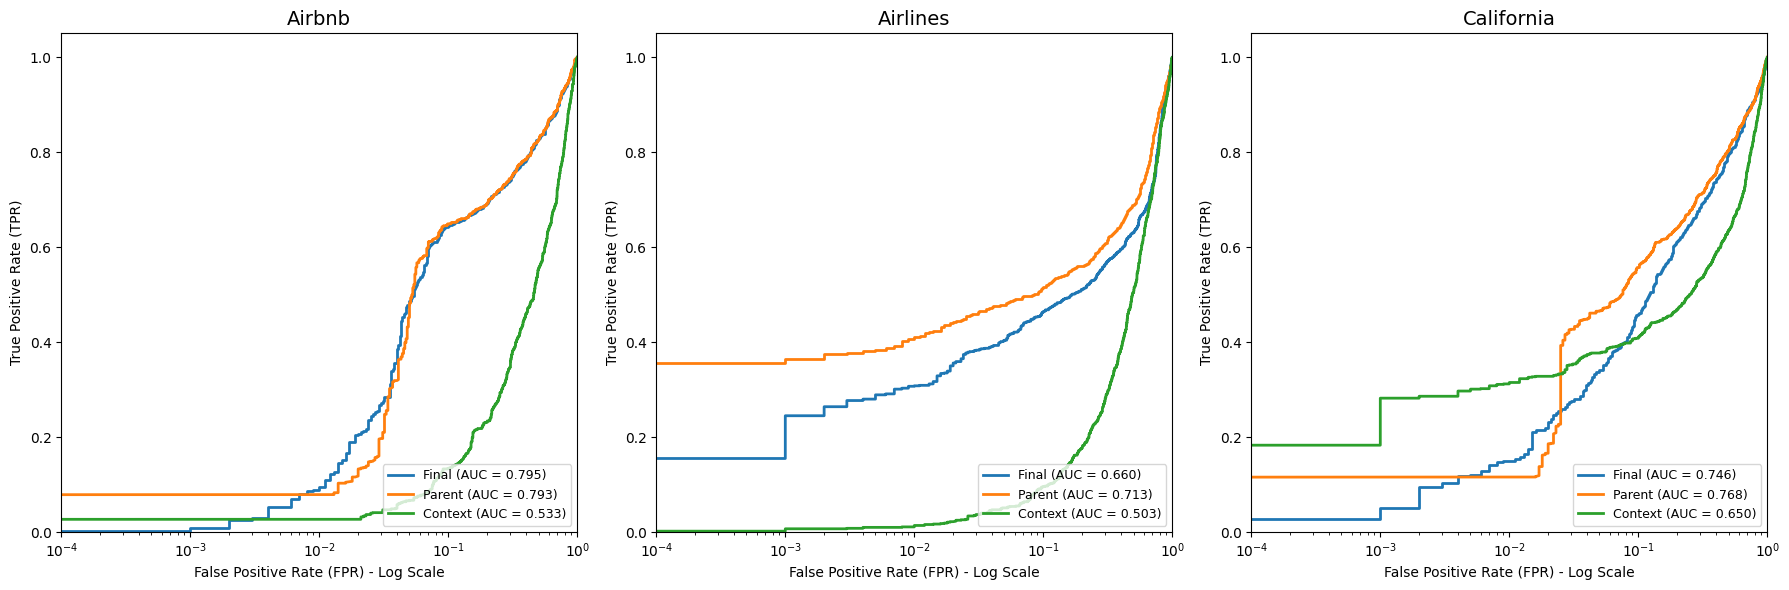

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
def plot_clava_subplot(entry, ax):
    """
    Plots the ROC curves for a single entry on a log-scaled axis.
    """
    method = entry.get('method', 'ClavaDDPm')
    dataset = entry.get('dataset', 'airbnb').capitalize()
    
    categories = {
        'full': 'Final',
        'target': 'Parent',
        'context': 'Context'
    }
    
    for key, label in categories.items():
        if key not in entry or 'scores' not in entry[key]:
            continue
            
        scores = np.array(entry[key]['scores'])
        n = len(scores)
        
        # Ground Truth: First half = 1, Second half = 0
        y_true = np.zeros(n)
        y_true[:n//2] = 1
        
        fpr, tpr, _ = roc_curve(y_true, scores)
        roc_auc = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.3f})')

    # Log Scale Adjustments
    ax.set_xscale('log') # Sets the x-axis to log scale
    
    # 3. Set specific log limits
    ax.set_xlim([0.0001, 1.0])
    ax.set_ylim([0.0, 1.05])
    
    # 4. Refined Grid for Log Scale
    
    ax.set_xlabel('False Positive Rate (FPR) - Log Scale')
    ax.set_ylabel('True Positive Rate (TPR)')
    ax.set_title(dataset, fontsize=14)
    ax.legend(loc="lower right", fontsize=9)
    
    # Grid lines look better with 'both' (major and minor) for log scales
    ax.grid(False)
# The rest of your plotting logic remains the same
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
indices = [0, 6, 4]
for i, idx in enumerate(indices):
    plot_clava_subplot(all_results[idx], axes[i])

plt.tight_layout()
plt.show()

# Table 3

In [110]:
# 1. Define your specific target rows
targets = [
    ('clava_ddpm', 'airbnb', 42),
    ('clava_ddpm', 'airlines', 42),
    ('clava_ddpm', 'california', 43)
]
cols_to_keep = ['method', 'dataset', 'seed', 'auc_roc', 'tpr_at_fpr_0', 'tpr_at_fpr_0.001']

specific_runs = (
    df_single_table
    .query("table_type == 'parent' and status == 'success' and attacker != 'Classifier' and attacker == 'DCR'")
    .set_index(['method', 'dataset', 'seed'])
    .loc[lambda x: x.index.isin(targets)]
    .reset_index()
    [cols_to_keep] # Filter columns right here
)

# 2. Extract only the specific 4 metrics for 'full', 'target', and 'context'
extracted_data = []
for item in all_results:
    row = {'method': item['method'], 'dataset': item['dataset'], 'seed': item['seed']}
    
    for cat in ['full', 'target', 'context']:
        res = item.get(cat, {}).get('results', {})
        row[f'{cat}_auc_roc'] = res.get('auc_roc')
        row[f'{cat}_tpr_at_fpr_0'] = res.get('tpr_at_fpr_0')
        row[f'{cat}_tpr_at_fpr_0.001'] = res.get('tpr_at_fpr_0.001')
        row[f'{cat}_tpr_at_fpr_0.01'] = res.get('tpr_at_fpr_0.01')
        
    extracted_data.append(row)

df_metrics = pd.DataFrame(extracted_data)

# 3. Join them
# This keeps the columns from specific_runs and attaches the new metrics
final_df = pd.merge(specific_runs, df_metrics, on=['method', 'dataset', 'seed'], how='inner')

# 4. Final filter of columns (Identifiers + your requested metrics)
target_metrics = [c for c in final_df.columns if any(m in c for m in ['auc_roc', 'tpr_at_fpr_0', 'tpr_at_fpr_0.001', 'tpr_at_fpr_0.01'])]
final_df = final_df[['method', 'dataset', 'seed'] + target_metrics].drop(columns='seed')

(final_df)

,method,dataset,auc_roc,tpr_at_fpr_0,tpr_at_fpr_0.001,full_auc_roc,full_tpr_at_fpr_0,full_tpr_at_fpr_0.001,full_tpr_at_fpr_0.01,target_auc_roc,target_tpr_at_fpr_0,target_tpr_at_fpr_0.001,target_tpr_at_fpr_0.01,context_auc_roc,context_tpr_at_fpr_0,context_tpr_at_fpr_0.001,context_tpr_at_fpr_0.01
0,clava_ddpm,airbnb,0.781238,0.000,0.005655,0.794686,0.002,0.009,0.094,0.793285,0.000,0.006077,0.060769,0.532643,0.000,0.00135,0.0135
1,clava_ddpm,california,0.780671,0.000,0.009280,0.746011,0.028,0.051,0.150,0.768436,0.000,0.007250,0.072500,0.650264,0.183,0.28200,0.3150
2,clava_ddpm,airlines,0.689992,0.055,0.089000,0.659946,0.155,0.245,0.308,0.713031,0.356,0.365000,0.411000,0.502561,0.002,0.00700,0.0140


In [101]:
import pandas as pd

# 1. Extract and flatten only the relevant metrics
# We define which keys we want to pull from the nested structure
rows = []
for entry in all_results:
    row = {
        'method': entry['method'],
        'dataset': entry['dataset'],
        'seed': entry['seed']
    }
    
    # Define which result categories to include (e.g., 'full', 'target')
    for category in ['full', 'target', 'context']:
        if category in entry:
            res = entry[category]['results']
            row[f'{category}_auc_roc'] = res.get('auc_roc')
            row[f'{category}_tpr_at_fpr_0'] = res.get('tpr_at_fpr_0')
            row[f'{category}_tpr_at_fpr_0.001'] = res.get('tpr_at_fpr_0.001')
            row[f'{category}_tpr_at_fpr_0.01'] = res.get('tpr_at_fpr_0.01')
            
    rows.append(row)

df_metrics = pd.DataFrame(rows)

# 2. Join with your filtered specific_runs
final_df = pd.merge(
    specific_runs, 
    df_metrics, 
    on=['method', 'dataset', 'seed'], 
    how='inner'
)

# 3. Keep only columns from specific_runs + the new metrics
cols_to_keep = list(specific_runs.columns) + [c for c in df_metrics.columns if 'auc_roc' in c or 'tpr' in c]
final_df = final_df[cols_to_keep]

(final_df)

,method,dataset,seed,table_type,attacker,status,auc_roc,tpr_at_fpr_0,tpr_at_fpr_0.001,tpr_at_fpr_0.01,...,full_tpr_at_fpr_0.001,full_tpr_at_fpr_0.01,target_auc_roc,target_tpr_at_fpr_0,target_tpr_at_fpr_0.001,target_tpr_at_fpr_0.01,context_auc_roc,context_tpr_at_fpr_0,context_tpr_at_fpr_0.001,context_tpr_at_fpr_0.01
0,clava_ddpm,airbnb,42,parent,DCR,success,0.781238,0.000,0.005655,0.056552,...,0.009,0.094,0.793285,0.000,0.006077,0.060769,0.532643,0.000,0.00135,0.0135
1,clava_ddpm,california,43,parent,DCR,success,0.780671,0.000,0.009280,0.092800,...,0.051,0.150,0.768436,0.000,0.007250,0.072500,0.650264,0.183,0.28200,0.3150
2,clava_ddpm,airlines,42,parent,DCR,success,0.689992,0.055,0.089000,0.122000,...,0.245,0.308,0.713031,0.356,0.365000,0.411000,0.502561,0.002,0.00700,0.0140


In [175]:
import pandas as pd

processed_rows = []

# 1. Create a lookup for all_results using (method, dataset, seed) as the key
results_lookup = {
    (item['method'], item['dataset'], item['seed']): item 
    for item in all_results
}

# 2. Loop through your TARGETS to ensure no duplicates and correct order
for method, dataset, seed in targets:
    # Get the specific result dictionary
    item = results_lookup.get((method, dataset, seed))
    if not item: continue
    
    # Get the specific Vanilla row from specific_runs
    vanilla_row = specific_runs[
        (specific_runs['method'] == method) & 
        (specific_runs['dataset'] == dataset) & 
        (specific_runs['seed'] == seed)
    ].iloc[0]
    
    metrics_mapping = [
        ('AUC', 'auc_roc'),
        ('TPR@0', 'tpr_at_fpr_0'),
        ('TPR@$10^{-3}$', 'tpr_at_fpr_0.001'),
        ('TPR@$10^{-2}$', 'tpr_at_fpr_0.01')
    ]
    
    dataset_label = dataset.capitalize()
    
    for label, key in metrics_mapping:
        processed_rows.append({
            'Dataset': dataset_label,
            'Metric': label,
            'Vanilla': vanilla_row.get(key, 0.0),
            'z_target': item['target']['results'].get(key, 0.0),
            'z_context': item['context']['results'].get(key, 0.0),
            'z_final': item['full']['results'].get(key, 0.0)
        })

# --- PRINTING THE TABLE ---
current_ds = ""
for i, row in enumerate(processed_rows):
    is_new_ds = row['Dataset'] != current_ds
    ds_cell = f"\\multirow{{4}}*{{{row['Dataset']}}}" if is_new_ds else ""
    current_ds = row['Dataset']
    
    # Values
    v, zt, zc, zf = row['Vanilla'], row['z_target'], row['z_context'], row['z_final']

    # Logic to find max and bold it (Optional)
    vals = [v, zt, zc, zf]
    max_val = max(vals)
    formatted = []
    for val in vals:
        s = f"{val:.3f}"
        formatted.append(f"\\textbf{{{s}}}" if val == max_val and val > 0 else s)

    print(f"{ds_cell} & {row['Metric']} & {' & '.join(formatted)} \\\\")
    
    if (i + 1) % 4 == 0:
        print("\\hline")

\multirow{4}*{Airbnb} & AUC & 0.781 & 0.793 & 0.533 & \textbf{0.795} \\
 & TPR@0 & 0.000 & 0.000 & 0.000 & \textbf{0.002} \\
 & TPR@$10^{-3}$ & 0.006 & 0.006 & 0.001 & \textbf{0.009} \\
 & TPR@$10^{-2}$ & 0.000 & 0.061 & 0.013 & \textbf{0.094} \\
\hline
\multirow{4}*{Airlines} & AUC & 0.690 & \textbf{0.713} & 0.503 & 0.660 \\
 & TPR@0 & 0.055 & \textbf{0.356} & 0.002 & 0.155 \\
 & TPR@$10^{-3}$ & 0.089 & \textbf{0.365} & 0.007 & 0.245 \\
 & TPR@$10^{-2}$ & 0.000 & \textbf{0.411} & 0.014 & 0.308 \\
\hline
\multirow{4}*{California} & AUC & \textbf{0.781} & 0.768 & 0.650 & 0.746 \\
 & TPR@0 & 0.000 & 0.000 & \textbf{0.183} & 0.028 \\
 & TPR@$10^{-3}$ & 0.009 & 0.007 & \textbf{0.282} & 0.051 \\
 & TPR@$10^{-2}$ & 0.000 & 0.072 & \textbf{0.315} & 0.150 \\
\hline


# Table 4

In [150]:
import json
import pandas as pd
from pathlib import Path
import numpy as np
from collections import defaultdict

def parse_filepath(filepath):
    """
    Extract metadata from filepath using relative indexing from the filename.
    Structure: .../{method}/{dataset}/{filename}.jsonl
    """
    path = Path(filepath)
    parts = path.parts
    
    # Using negative indexing ensures we always get the right folders 
    # relative to the filename, regardless of leading '../' or '/'
    # parts[-1] is the filename (seed_42.jsonl)
    # parts[-2] is the dataset (airbnb)
    # parts[-3] is the method (clava_ddpm)
    
    method = parts[-3] if len(parts) >= 3 else None
    dataset = parts[-2] if len(parts) >= 2 else None
    
    # Extract seed from filename
    filename = path.stem  # seed_42
    seed = None
    if 'seed_' in filename:
        try:
            seed = int(filename.split('seed_')[-1])
        except ValueError:
            seed = None
    
    return {
        'method': method,
        'dataset': dataset,
        'seed': seed,
        'filepath': str(filepath)
    }


def load_jsonl_mtmia(filepath):
    """
    Load MTMIA results from a JSONL file and return the last epoch.
    
    Returns:
        Dict with epoch number and results for each evaluation type (full, parent, child, etc.)
    """
    epochs = []
    
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip():
                data = json.loads(line.strip())
                epochs.append(data)
    
    if not epochs:
        return None
    
    # Get the last epoch
    last_epoch = epochs[-1]
    
    return last_epoch


def load_all_results(result_files):
    """
    Load all MTMIA JSONL files and organize by metadata.
    
    Returns:
        List of dicts, each containing:
        - method, dataset, seed (metadata)
        - epoch (last epoch number)
        - results for each evaluation type
    """
    all_results = []
    
    for filepath in result_files:
        metadata = parse_filepath(filepath)
        
        try:
            last_epoch_data = load_jsonl_mtmia(filepath)
            
            if last_epoch_data is None:
                print(f"No data found in {filepath}")
                continue
            
            # Combine metadata with last epoch results
            entry = {
                **metadata,
                'epoch': last_epoch_data.get('epoch'),
                **last_epoch_data  # This includes 'full', 'parent', 'child', etc.
            }
            all_results.append(entry)
            
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    return all_results


def results_to_dataframe(all_results):
    """
    Convert nested MTMIA results to a flat DataFrame for analysis.
    
    Each row represents: method | dataset | seed | epoch | eval_type | metric | value
    """
    rows = []
    
    for entry in all_results:
        method = entry['method']
        dataset = entry['dataset']
        seed = entry['seed']
        epoch = entry['epoch']
        
        # Iterate through evaluation types (full, parent, child, etc.)
        for eval_type, eval_data in entry.items():
            # Skip metadata fields
            if eval_type in ['method', 'dataset', 'seed', 'epoch', 'filepath']:
                continue
            
            # Check if this is a results dict
            if isinstance(eval_data, dict) and 'results' in eval_data:
                results = eval_data['results']
                
                row = {
                    'method': method,
                    'dataset': dataset,
                    'seed': seed,
                    'epoch': epoch,
                    'eval_type': eval_type,
                }
                
                # Add all metrics as columns
                if isinstance(results, dict):
                    row.update(results)
                
                rows.append(row)
    
    return pd.DataFrame(rows)




# Define all result files
result_files = [
    # CLAVA DDPM results
    "../results/clava_ddpm/airbnb/mtmia_seed_42.jsonl",
    "../results/clava_ddpm/airbnb/mtmia_seed_43.jsonl",
    "../results/clava_ddpm/airbnb/mtmia_seed_44.jsonl",
    "../results/clava_ddpm/california/mtmia_seed_42.jsonl",
    "../results/clava_ddpm/california/mtmia_seed_43.jsonl",
    "../results/clava_ddpm/california/mtmia_seed_44.jsonl",
    "../results/clava_ddpm/airlines/mtmia_seed_42.jsonl",
    "../results/clava_ddpm/airlines/mtmia_seed_43.jsonl",
    "../results/clava_ddpm/airlines/mtmia_seed_44.jsonl",
    
    # RTF results
    "../results/rtf/airbnb/mtmia_seed_42.jsonl",
    "../results/rtf/airbnb/mtmia_seed_43.jsonl",
    "../results/rtf/airbnb/mtmia_seed_44.jsonl",
    "../results/rtf/california/mtmia_seed_42.jsonl",
    "../results/rtf/california/mtmia_seed_43.jsonl",
    "../results/rtf/california/mtmia_seed_44.jsonl",
    "../results/rtf/airlines/mtmia_seed_42.jsonl",
    "../results/rtf/airlines/mtmia_seed_43.jsonl",
    "../results/rtf/airlines/mtmia_seed_44.jsonl",
]

# Load all results
print("Loading MTMIA results...")
all_results = load_all_results(result_files)
print(f"Loaded {len(all_results)} result files")

all_results
# Convert to DataFrame
print("\nConverting to DataFrame...")
df = results_to_dataframe(all_results)

metrics = [
    "auc_roc",
    "tpr_at_fpr_0",
    "tpr_at_fpr_0.001",
    "tpr_at_fpr_0.01",

]



Loading MTMIA results...
Loaded 18 result files

Converting to DataFrame...


In [155]:
import os
import json
import sys
import numpy as np
import pandas as pd
# Get the absolute path to the directory 1 level up
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add it to sys.path if it's not already there
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# Now your imports will work
from src.utils import load_config
from src.synth_mia.attackers import dcr
from src.utils import load_config
from src.synth_mia.attackers import dcr

# -----------------------
# Helper functions
# -----------------------

def load_schema(schema_path):
    with open(schema_path, 'r') as f:
        return json.load(f)

def infer_table_names(schema):
    tables = schema['tables']
    parent_table = next(name for name, info in tables.items() if not info['parents'])
    child_table = next(name for name, info in tables.items() if info['parents'])
    return parent_table, child_table

def load_tables_with_ids(directory, parent_table, child_table):
    p_df = pd.read_csv(os.path.join(directory, f"{parent_table}.csv"))
    c_df = pd.read_csv(os.path.join(directory, f"{child_table}.csv"))

    p_id_col, c_id_col = f"{parent_table}_id", f"{child_table}_id"

    p_ids = p_df[p_id_col].values
    c_parent_ids = c_df[p_id_col].values

    p_data = p_df.drop(columns=[p_id_col]).astype(float).values
    c_data = c_df.drop(
        columns=[c for c in [p_id_col, c_id_col] if c in c_df.columns]
    ).astype(float).values

    return (p_data, p_ids), (c_data, c_parent_ids)

def broadcast_scores(parent_ids, scores, child_parent_ids):
    score_map = dict(zip(parent_ids, scores))
    return np.array([score_map[pid] for pid in child_parent_ids])

# -----------------------
# Dataset configuration
# -----------------------

DATASETS = {
    "airbnb": {
        "config": "../configs/airbnb.yaml",
        "schema": "../data/airbnb/dataset_meta.json",
    },
    "california": {
        "config": "../configs/california.yaml",
        "schema": "../data/california/dataset_meta.json",
    },
    "airlines": {
        "config": "../configs/airlines.yaml",
        "schema": "../data/airlines/dataset_meta.json",
    },
}

TRAIN_PATHS = [
    "../clava_synth/airbnb/seed_42/",
    "../clava_synth/airbnb/seed_43/",
    "../clava_synth/airbnb/seed_44/",
    "../clava_synth/california/seed_42/",
    "../clava_synth/california/seed_43/",
    "../clava_synth/california/seed_44/",
    "../clava_synth/airlines/seed_42/",
    "../clava_synth/airlines/seed_43/",
    "../clava_synth/airlines/seed_44/",
]

# -----------------------
# Main loop
# -----------------------

rows = []

for run_idx, train_path in enumerate(TRAIN_PATHS):
    # Change [1] to [2] to skip the '../' and 'clava_synth/' parts
    parts = train_path.strip("/").split("/")
    dataset = parts[2] 
    seed = parts[3].split("_")[-1]

    cfg = DATASETS[dataset]
    # ... rest of your code

    cfg = DATASETS[dataset]
    config = load_config(cfg["config"])
    schema = load_schema(cfg["schema"])

    parent_table, child_table = infer_table_names(schema)
    splits = config["dataset_paths"]
    splits = {k: os.path.join("..", v) for k, v in config["dataset_paths"].items()}    
    splits["train"] = train_path

    # Load data
    (mem_p, mem_p_ids), (mem_c, mem_c_p_ids) = load_tables_with_ids(
        splits["mem"], parent_table, child_table
    )
    (non_p, non_p_ids), (non_c, non_c_p_ids) = load_tables_with_ids(
        splits["non_mem"], parent_table, child_table
    )

    # Load scores for this run
    scores = all_results[run_idx]["full"]["scores"]
    mem_scores = scores[:len(mem_p)]
    non_scores = scores[len(mem_p):]

    # Broadcast to children
    mem_child_scores = broadcast_scores(
        mem_p_ids, mem_scores, mem_c_p_ids
    )
    non_child_scores = broadcast_scores(
        non_p_ids, non_scores, non_c_p_ids
    )

    full_scores = np.concatenate([mem_child_scores, non_child_scores])
    labels = np.concatenate([
        np.ones(len(mem_child_scores)),
        np.zeros(len(non_child_scores))
    ])

    # Run evaluation
    eval_dict = dcr().eval(
        labels,
        full_scores,
        metrics=["roc"]
    )

    # Flatten into one row
    row = {
        "dataset": dataset,
        "seed": int(seed),
        **eval_dict
    }

    rows.append(row)

# Final dataframe
eval_df = pd.DataFrame(rows)
metrics = [
    "auc_roc",
    "tpr_at_fpr_0",
    "tpr_at_fpr_0.001",
    "tpr_at_fpr_0.01",

]
mt_mia_grouped = eval_df.groupby("dataset")[metrics].agg(["mean", "std"])
mt_mia_grouped.round(2)


auc_roc       tpr_at_fpr_0       tpr_at_fpr_0.001        \
              mean   std         mean   std             mean   std   
dataset                                                              
airbnb        0.80  0.01         0.01  0.00             0.01  0.00   
airlines      0.66  0.01         0.17  0.03             0.17  0.03   
california    0.71  0.04         0.05  0.05             0.07  0.04   

           tpr_at_fpr_0.01        
                      mean   std  
dataset                           
airbnb                0.09  0.00  
airlines              0.30  0.05  
california            0.15  0.08